In [1]:
import sys
sys.path.insert(1, '/home/fainx/MyPythonLibrary/MAR-RECAP/libmar/')
import climbasis as climb
from climbasis import *
import domain as dom
import myplot
import numpy.ma as ma
from myplot import *
import obsinfo as obs
from obsinfo import *
from datetime import datetime
import mar
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

In [5]:
iyr=1980;fyr=2024
domain='GRf'
domain_2 = 'GRp'
latS,latN,lonW,lonE,latlim,lonlim=dom.coord_domain(domain)  
print(latS,latN,lonW,lonE)

# Removed pixels on domain boundaries
k =10

36 41 67 78


In [99]:
# Fedchenko area
#lon
w=24 ; x=34
#lat
y=40 ; z=52

In [101]:
# Ice thresold, 2025_28_11_Grp*.nc
ice_threshold = 40

In [3]:
# Jasgulem ice core coordinates:
jasg_lat = 38.54063
jasg_lon = 72.269816

In [6]:
sourceData_1='/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/' + domain_2 +'/spin2/work/monthly/'
sourceData_2='/bettik/PROJECTS/pr-regional-climate/fainx/'
folder_figure = '/bettik/PROJECTS/pr-regional-climate/fainx/figures/' + domain_2 +'/'

In [4]:
season_list = ["DJF", "MAM", "JJA", "SON"]

In [121]:
seb_dataset = {
    "SHF": ds_SHF,
    "LHF": ds_LHF,
    "ME":  ds_ME,
    "LWD": ds_LWD,
    "LWU": ds_LWU,
    "SWD": ds_SWD,
    "SWU": ds_SWU,
    "GF":  ds_GF,
}

In [105]:
# MAR topography
sourceDataGrid='/home/amoryc/'
fileName_grF='NST.2000.01.01.00.GRp.nc'
ds_grF= xr.open_dataset(sourceDataGrid+fileName_grF)

# Enlever k pixels sur les contours
ds_lon=ds_grF.LON[k:-k,k:-k]
ds_lat=ds_grF.LAT[k:-k,k:-k]
ds_SH=ds_grF.SH[k:-k,k:-k]
ds_ICE=ds_grF.ICE[k:-k,k:-k]

ds_lon = ds_lon.rename({"y": "Y", "x": "X"})
ds_lat = ds_lat.rename({"y": "Y", "x": "X"})
ds_SH = ds_SH.rename({"y": "Y", "x": "X"})
ds_ICE = ds_ICE.rename({"y": "Y", "x": "X"})

ds_lon = ds_lon.assign_coords(X=np.round(ds_lon.X.values))
ds_lon = ds_lon.assign_coords(Y=np.round(ds_lon.Y.values))

ds_lat = ds_lat.assign_coords(X=np.round(ds_lat.X.values))
ds_lat = ds_lat.assign_coords(Y=np.round(ds_lat.Y.values))

ds_SH = ds_SH.assign_coords(X=np.round(ds_SH.X.values))
ds_SH = ds_SH.assign_coords(Y=np.round(ds_SH.Y.values))

ds_ICE = ds_ICE.assign_coords(X=np.round(ds_ICE.X.values))
ds_ICE = ds_ICE.assign_coords(Y=np.round(ds_ICE.Y.values))

In [8]:
# Identifier les indices X et Y correspondant au point de grille ou se trouve la carotte Jasgulem

# distance sur grille
dist = np.sqrt((ds_lat - jasg_lat)**2 + (ds_lon - jasg_lon)**2)
# index 1D du minimum
idx_1d = dist.argmin().item()
# conversion en indices 2D (Y, X)
iY, iX = np.unravel_index(idx_1d, dist.shape)

print("Indice Y :", iY)
print("Indice X :", iX)
print("Latitude trouvée :", ds_lat[iY, iX].item())
print("Longitude trouvée :", ds_lon[iY, iX].item())

Indice Y : 26
Indice X : 47
Latitude trouvée : 38.54820251464844
Longitude trouvée : 72.30000305175781


### Loading the SEB variables

In [21]:
# Latent Heat Flux (W/m2)
variable='LHF' 

fileNameF= variable+'_mon_MARv3.14_ER5_spin2_'+domain_2+'_1980-2024.nc'
ds= xr.open_dataset(sourceData_1+fileNameF)[variable].load()

ds = ds.assign_coords(X=np.round(ds.X.values))
ds = ds.assign_coords(Y=np.round(ds.Y.values))
ds = ds.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_LHF = ds[:,k:-k,k:-k]

In [34]:
# Sensible Heat Flux (W/m2)
variable='SHF' 

fileNameF= variable+'_mon_MARv3.14_ER5_spin2_'+domain_2+'_1980-2024.nc'
ds= xr.open_dataset(sourceData_1+fileNameF)[variable].load()

ds = ds.assign_coords(X=np.round(ds.X.values))
ds = ds.assign_coords(Y=np.round(ds.Y.values))
ds = ds.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_SHF = ds[:,k:-k,k:-k]

In [70]:
# Melt (mmWE/day)
variable='ME' 

fileNameF= variable+'_mon_MARv3.14_ER5_spin2_'+domain_2+'_1980-2024.nc'
ds= xr.open_dataset(sourceData_1+fileNameF)[variable].isel(SECTOR1_1=0).load()

ds = ds.assign_coords(X=np.round(ds.X.values))
ds = ds.assign_coords(Y=np.round(ds.Y.values))
ds = ds.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_ME = ds[:,k:-k,k:-k]

In [28]:
# Long Wave Downward (W/m2)
variable='LWD' 

fileNameF= variable+'_mon_MARv3.14_ER5_spin2_'+domain_2+'_1980-2024.nc'
ds= xr.open_dataset(sourceData_1+fileNameF)[variable].load()

ds = ds.assign_coords(X=np.round(ds.X.values))
ds = ds.assign_coords(Y=np.round(ds.Y.values))
ds = ds.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_LWD = ds[:,k:-k,k:-k]

In [29]:
# Long Wave Upward (W/m2)
variable='LWU' 

fileNameF= variable+'_mon_MARv3.14_ER5_spin2_'+domain_2+'_1980-2024.nc'
ds= xr.open_dataset(sourceData_1+fileNameF)[variable].load()

ds = ds.assign_coords(X=np.round(ds.X.values))
ds = ds.assign_coords(Y=np.round(ds.Y.values))
ds = ds.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_LWU = ds[:,k:-k,k:-k]

In [37]:
# Short Wave Downward (W/m2)
variable='SWD' 

fileNameF= variable+'_mon_MARv3.14_ER5_spin2_'+domain_2+'_1980-2024.nc'
ds= xr.open_dataset(sourceData_1+fileNameF)[variable].load()

ds = ds.assign_coords(X=np.round(ds.X.values))
ds = ds.assign_coords(Y=np.round(ds.Y.values))
ds = ds.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_SWD = ds[:,k:-k,k:-k]

In [41]:
# Short Wave Upward (W/m2)
variable='SWU' 

fileNameF= variable+'_mon_MARv3.14_ER5_spin2_'+domain_2+'_1980-2024.nc'
ds= xr.open_dataset(sourceData_1+fileNameF)[variable].load()

ds = ds.assign_coords(X=np.round(ds.X.values))
ds = ds.assign_coords(Y=np.round(ds.Y.values))
ds = ds.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_SWU = ds[:,k:-k,k:-k]

In [69]:
# Ground Flux
variable='GF' 

fileNameF= variable+'_monmean_MARv3.14_ER5_spin2_'+domain_2+'_1980-2024.nc'
ds= xr.open_dataset(sourceData_1+fileNameF)[variable].load()

ds = ds.assign_coords(X=np.round(ds.X.values))
ds = ds.assign_coords(Y=np.round(ds.Y.values))
ds = ds.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_GF = ds[:,k:-k,k:-k]

#### SEB for Fedchenko Glacier

In [106]:
ds_ICE_expanded = ds_ICE.expand_dims({"time": ds_LHF.time}).transpose("time", "Y", "X")

In [123]:
ds_ICE_Fed = ds_ICE[w:x,y:z]
ds_lon_Fed = ds_lon[w:x,y:z]
ds_lat_Fed = ds_lat[w:x,y:z]
ds_SH_Fed = ds_SH[w:x,y:z]

In [124]:
print('min atitude of selected Fechenko glacier area: ', ds_SH_Fed.min())
print('max atitude of selected Fechenko glacier area: ', ds_SH_Fed.max())
print('mean atitude of selected Fechenko glacier area: ', ds_SH_Fed.mean(skipna=True))
count = np.count_nonzero(~np.isnan(ds_SH_Fed))
count_all = ds_SH_Fed.size
print('mean atitude of selected Fechenko glacier area: ',count)
print('mean atitude of selected Fechenko glacier area: ',count_all)

min atitude of selected Fechenko glacier area:  <xarray.DataArray 'SH' ()> Size: 4B
array(2857.7615, dtype=float32)
max atitude of selected Fechenko glacier area:  <xarray.DataArray 'SH' ()> Size: 4B
array(5668.944, dtype=float32)
mean atitude of selected Fechenko glacier area:  <xarray.DataArray 'SH' ()> Size: 4B
array(4452.6855, dtype=float32)
mean atitude of selected Fechenko glacier area:  120
mean atitude of selected Fechenko glacier area:  120


In [122]:
ds_Fed = xr.Dataset({
    name: xr.where(ds_ICE_expanded > ice_threshold, ds, np.nan)
    for name, ds in seb_dataset.items()
}).isel(X=slice(w, x), Y=slice(y, z))
#dsF['ME']

### SEB at Jasgulem firn grid cell

Indice Y : 26
Indice X : 47


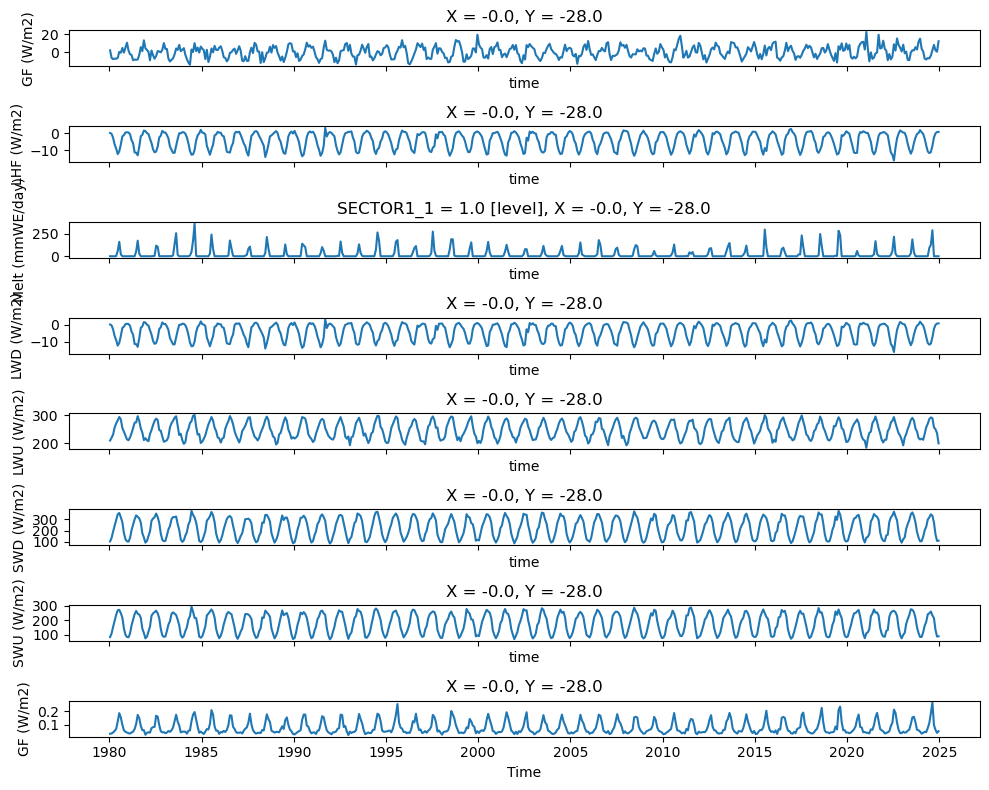

In [72]:
# Plot V1

print("Indice Y :", iY)
print("Indice X :", iX)

fig, axes = plt.subplots(
    nrows=8,
    ncols=1,
    figsize=(10, 8),
    sharex=True
)

# Panel 1 : SHF
ds_SHF.isel(Y=iY, X=iX).plot(ax=axes[0])
axes[0].set_ylabel("GF (W/m2)")

# Panel 2 : LHF
ds_LHF.isel(Y=iY, X=iX).plot(ax=axes[1])
axes[1].set_ylabel("LHF (W/m2)")

# Panel 3 : ME
ds_ME.isel(Y=iY, X=iX).plot(ax=axes[2])
axes[2].set_ylabel("Melt (mmWE/day)")

# Panel 4 : LWD
ds_LHF.isel(Y=iY, X=iX).plot(ax=axes[3])
axes[3].set_ylabel("LWD (W/m2)")

# Panel 5 : LWU
ds_LWU.isel(Y=iY, X=iX).plot(ax=axes[4])
axes[4].set_ylabel("LWU (W/m2)")

# Panel 6 : SWD
ds_SWD.isel(Y=iY, X=iX).plot(ax=axes[5])
axes[5].set_ylabel("SWD (W/m2)")

# Panel 7 : SWU
ds_SWU.isel(Y=iY, X=iX).plot(ax=axes[6])
axes[6].set_ylabel("SWU (W/m2)")

# Panel 8 : GF
ds_GF.isel(Y=iY, X=iX).plot(ax=axes[7])
axes[7].set_ylabel("GF (W/m2)")
axes[7].set_xlabel("Time")

plt.tight_layout()
plt.show()

Indice Y : 26
Indice X : 47


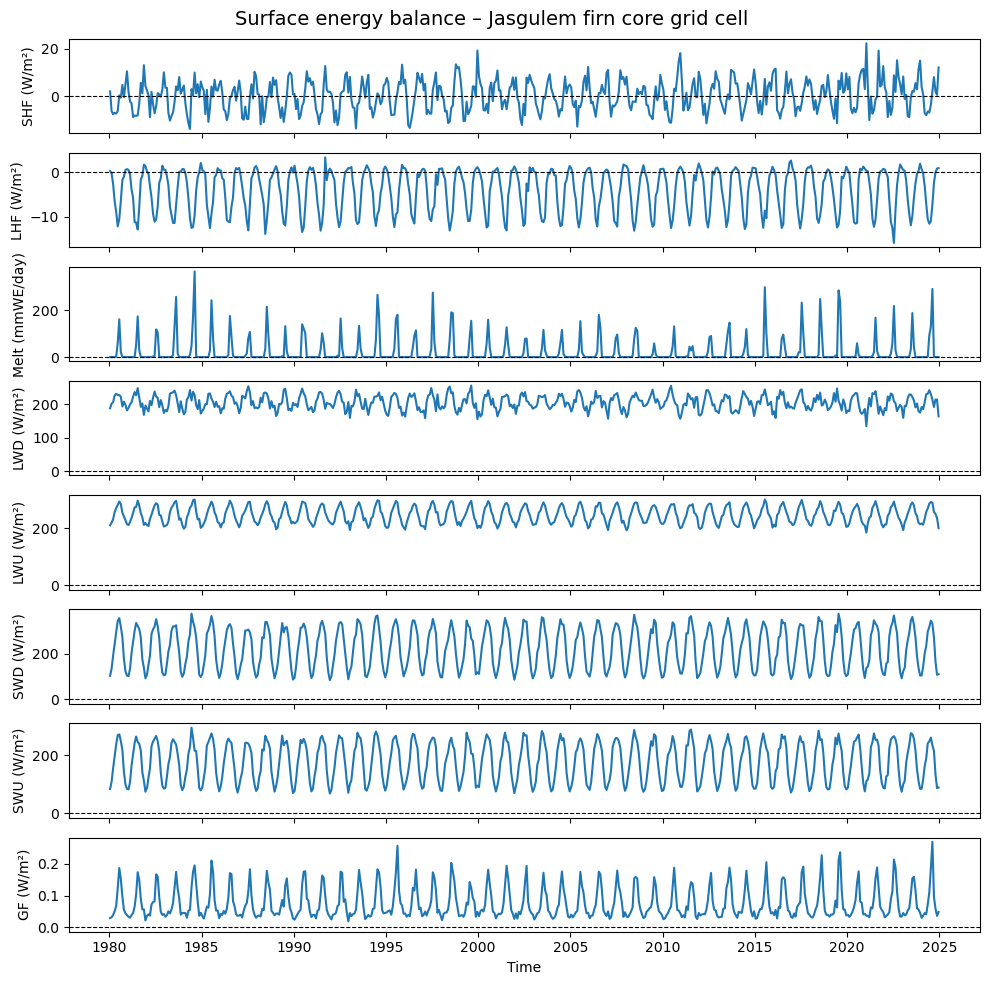

In [96]:
print("Indice Y :", iY)
print("Indice X :", iX)

fig, axes = plt.subplots(
    nrows=8,
    ncols=1,
    figsize=(10, 10),
    sharex=True
)

datasets = [
    ds_SHF, ds_LHF, ds_ME, ds_LWD,
    ds_LWU, ds_SWD, ds_SWU, ds_GF
]

ylabels = [
    "SHF (W/m²)", "LHF (W/m²)", "Melt (mmWE/day)",
    "LWD (W/m²)", "LWU (W/m²)",
    "SWD (W/m²)", "SWU (W/m²)",
    "GF (W/m²)"
]

# plots
for i, (ax, ds, yl) in enumerate(zip(axes, datasets, ylabels)):
    ds.isel(Y=iY, X=iX).plot(
        ax=ax,
    )
    ax.set_ylabel(yl)
    ax.set_title("")
    ax.set_xlabel("")
    ax.axhline(0, color="k", linewidth=0.8, linestyle="--")

axes[-1].set_xlabel("Time")

# Titre global
fig.suptitle(
    f"Surface energy balance – Jasgulem firn core grid cell ",
    fontsize=14
)

plt.subplots_adjust(top=0.93)
plt.tight_layout()
plt.show()

Indice Y : 26
Indice X : 47


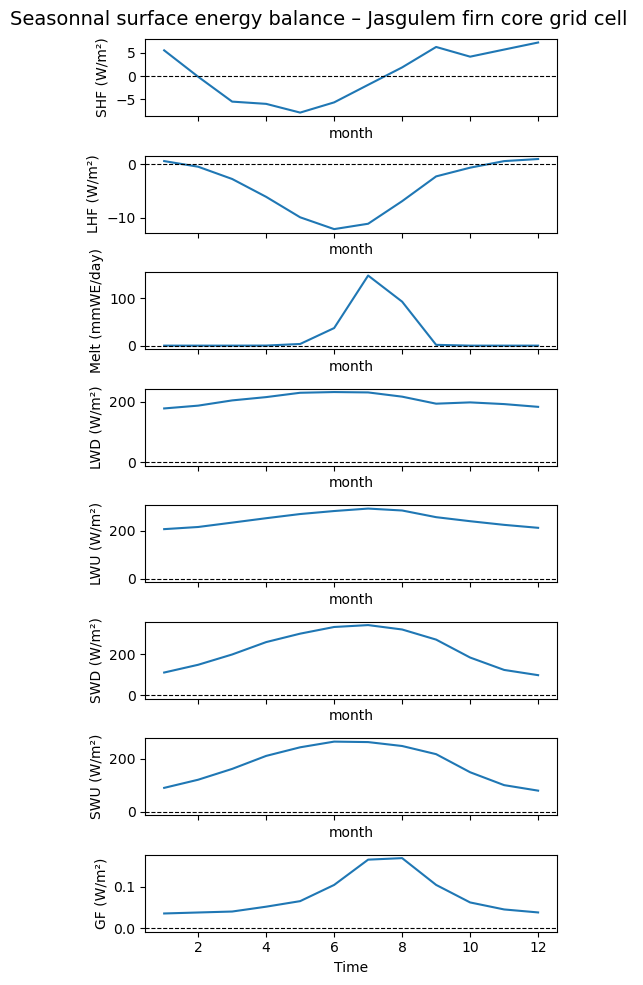

In [95]:
print("Indice Y :", iY)
print("Indice X :", iX)

fig, axes = plt.subplots(
    nrows=8,
    ncols=1,
    figsize=(5, 10),
    sharex=True
)

datasets = [
    ds_SHF.groupby('time.month').mean('time', skipna=True), 
    ds_LHF.groupby('time.month').mean('time', skipna=True), 
    ds_ME.groupby('time.month').mean('time', skipna=True), 
    ds_LWD.groupby('time.month').mean('time', skipna=True),
    ds_LWU.groupby('time.month').mean('time', skipna=True), 
    ds_SWD.groupby('time.month').mean('time', skipna=True),
    ds_SWU.groupby('time.month').mean('time', skipna=True),
    ds_GF.groupby('time.month').mean('time', skipna=True)
]

ylabels = [
    "SHF (W/m²)", "LHF (W/m²)", "Melt (mmWE/day)",
    "LWD (W/m²)", "LWU (W/m²)",
    "SWD (W/m²)", "SWU (W/m²)",
    "GF (W/m²)"
]

# plots
for i, (ax, ds, yl) in enumerate(zip(axes, datasets, ylabels)):
    ds.isel(Y=iY, X=iX).plot(
        ax=ax,
    )

    ax.set_ylabel(yl)
    ax.set_title("")
    ax.axhline(0, color="k", linewidth=0.8, linestyle="--")

axes[-1].set_xlabel("Time")

# Titre global
fig.suptitle(
    f"Seasonnal surface energy balance – Jasgulem firn core grid cell ",
    fontsize=14
)

plt.subplots_adjust(top=0.93)
plt.tight_layout()
plt.show()


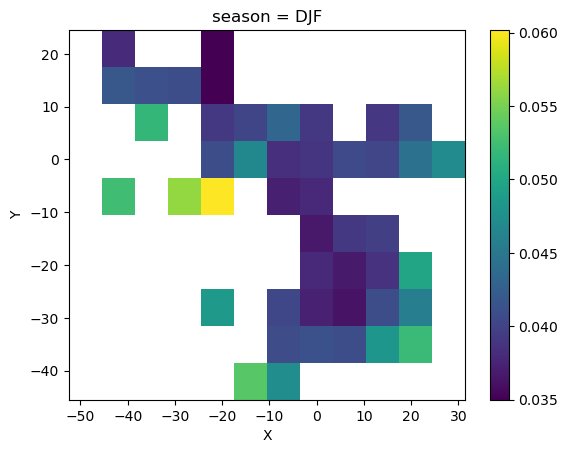

In [117]:
toto = dsF_GF_Fed.groupby('time.season').mean('time', skipna=True)
toto.isel(season=0).plot()

In [130]:
#Exclude the upper z-level integrating only 1 grid cell:
max_elev_bin=5500

elev_bins = np.arange(0, np.nanmax(max_elev_bin) + 250, 250)
#Consider all altitudinal level possible::
elev_bin_labels = (elev_bins[:-1] + elev_bins[1:]) / 2
elev_bin_labels

array([ 125.,  375.,  625.,  875., 1125., 1375., 1625., 1875., 2125.,
       2375., 2625., 2875., 3125., 3375., 3625., 3875., 4125., 4375.,
       4625., 4875., 5125., 5375.])